# Resident Reintegration Readiness Predictor
## Lighthouse Sanctuary — INTEX W26

---

## 1. Business Understanding

### Problem Statement
Lighthouse Sanctuary’s social workers manage caseloads of up to 60 girls across 9 safehouses. Each resident is on a unique reintegration journey — some are ready to return to family or move into independent living, while others require continued intensive support. Without a data-driven tool, prioritization relies entirely on individual social worker judgment, which is valuable but inconsistent and hard to scale.

### Modeling Goal
This pipeline is **predictive**: given a resident’s aggregated clinical and behavioral record, predict whether she is **ready for reintegration** or still requires continued care. This allows social workers to objectively identify who is ready, who needs more support, and allocate their time accordingly.

### Target Variable
**`is_ready`** — a binary label engineered from `reintegration_status`:
- **1 (Ready):** `reintegration_status` is `Completed` or `In Progress`
- **0 (Not Ready):** `reintegration_status` is `Not Started` or `On Hold`

This is a **classification** problem.

### Data Sources
Six tables are joined to create one modeling-ready row per resident:
- `residents` — base table (60 rows)
- `process_recordings` — counseling session records (~2,819 rows)
- `health_wellbeing_records` — monthly health scores (~534 rows)
- `education_records` — monthly academic progress (~534 rows)
- `incident_reports` — behavioral and safety incidents (~100 rows)
- `intervention_plans` — structured care goals (~180 rows)

### Success Metrics
- **ROC-AUC** — primary metric; measures discrimination ability across all thresholds
- **F1-Score** — balanced precision/recall for the positive class
- **Classification report** — full breakdown by class
- All compared against a naive baseline (predict majority class for every resident)

### Small Data Caveat
With only 60 residents, this is a genuinely small dataset for machine learning. We use `RepeatedStratifiedKFold` cross-validation to produce stable performance estimates. **Accuracy scores are not the emphasis here — the business story and feature importance are.** Which clinical factors most predict readiness is the actionable insight.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


---

## 2. Data Understanding

The resident dataset is the most structurally complex in this project. Rather than a single flat table, the story of each resident is distributed across six related tables:

- **`residents`** (60 rows) — demographics, case category, admission details, risk levels, reintegration status
- **`process_recordings`** (~2,819 rows) — individual counseling session notes with emotional states and progress flags
- **`health_wellbeing_records`** (~534 rows) — monthly physical health, nutrition, sleep, and energy scores
- **`education_records`** (~534 rows) — monthly academic progress, attendance, and program enrollment
- **`incident_reports`** (~100 rows) — behavioral and safety incidents with severity and resolution tracking
- **`intervention_plans`** (~180 rows) — structured rehabilitation goals with achievement status

This section explores each table individually to understand data quality, distributions, and patterns before any joins or modeling. The key question is: **what measurable signals in a resident's clinical and behavioral record might indicate readiness for reintegration?**

In [2]:
# ============================================================
# Imports
# ============================================================
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     RepeatedStratifiedKFold)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib
import json
from datetime import datetime, timezone

sns.set_style("whitegrid")
SEED = 42

In [3]:
# ============================================================
# 2a. Load all source tables
# ============================================================
USE_DATABASE = False  # flip to True once Azure SQL connection string is available

if USE_DATABASE:
    from sqlalchemy import create_engine
    CONNECTION_STRING = ""  # <-- paste Azure SQL connection string here
    engine = create_engine(CONNECTION_STRING)
    residents        = pd.read_sql("SELECT * FROM residents", engine)
    process_recs     = pd.read_sql("SELECT * FROM process_recordings", engine)
    health           = pd.read_sql("SELECT * FROM health_wellbeing_records", engine)
    education        = pd.read_sql("SELECT * FROM education_records", engine)
    incidents        = pd.read_sql("SELECT * FROM incident_reports", engine)
    plans            = pd.read_sql("SELECT * FROM intervention_plans", engine)
else:
    BASE = "/content/drive/MyDrive/School/Junior Core/Intex/lighthouse_csv_v7/"
    residents    = pd.read_csv(BASE + "residents.csv")
    process_recs = pd.read_csv(BASE + "process_recordings.csv")
    health       = pd.read_csv(BASE + "health_wellbeing_records.csv")
    education    = pd.read_csv(BASE + "education_records.csv")
    incidents    = pd.read_csv(BASE + "incident_reports.csv")
    plans        = pd.read_csv(BASE + "intervention_plans.csv")

print(f"residents:        {residents.shape}")
print(f"process_recs:     {process_recs.shape}")
print(f"health:           {health.shape}")
print(f"education:        {education.shape}")
print(f"incidents:        {incidents.shape}")
print(f"plans:            {plans.shape}")

residents:        (60, 49)
process_recs:     (2819, 15)
health:           (534, 14)
education:        (534, 10)
incidents:        (100, 12)
plans:            (180, 11)


In [4]:
# ============================================================
# 2b. EDA on residents (base table)
# ============================================================
display(residents.info())

print("\nreintegration_status distribution:")
display(residents["reintegration_status"].value_counts())

print("\ncurrent_risk_level distribution:")
display(residents["current_risk_level"].value_counts())

print("\ninitial_risk_level distribution:")
display(residents["initial_risk_level"].value_counts())

print("\ncase_status distribution:")
display(residents["case_status"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   resident_id               60 non-null     int64  
 1   case_control_no           60 non-null     object 
 2   internal_code             60 non-null     object 
 3   safehouse_id              60 non-null     int64  
 4   case_status               60 non-null     object 
 5   sex                       60 non-null     object 
 6   date_of_birth             60 non-null     object 
 7   birth_status              60 non-null     object 
 8   place_of_birth            60 non-null     object 
 9   religion                  60 non-null     object 
 10  case_category             60 non-null     object 
 11  sub_cat_orphaned          60 non-null     bool   
 12  sub_cat_trafficked        60 non-null     bool   
 13  sub_cat_child_labor       60 non-null     bool   
 14  sub_cat_phys

None


reintegration_status distribution:


,count
reintegration_status,
In Progress,21
Completed,19
On Hold,13
Not Started,7



current_risk_level distribution:


,count
current_risk_level,
Low,34
Medium,20
High,5
Critical,1



initial_risk_level distribution:


,count
initial_risk_level,
Medium,24
High,17
Low,14
Critical,5



case_status distribution:


,count
case_status,
Active,30
Closed,19
Transferred,11


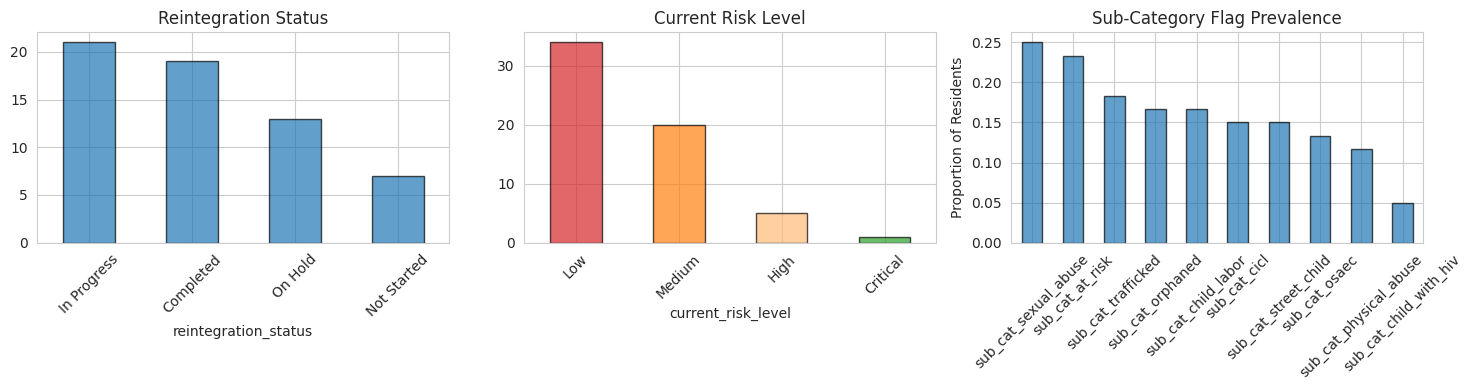

In [5]:
# ============================================================
# 2b (cont). Visualize key resident distributions
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

residents["reintegration_status"].value_counts().plot(
    kind="bar", ax=axes[0], edgecolor="black", alpha=0.7
)
axes[0].set_title("Reintegration Status")
axes[0].tick_params(axis="x", rotation=45)

residents["current_risk_level"].value_counts().plot(
    kind="bar", ax=axes[1], edgecolor="black", alpha=0.7,
    color=["#d62728", "#ff7f0e", "#ffbb78", "#2ca02c"]
)
axes[1].set_title("Current Risk Level")
axes[1].tick_params(axis="x", rotation=45)

# Sub-category flag prevalence
sub_cat_cols = [c for c in residents.columns if c.startswith("sub_cat_")]
sub_cat_rates = residents[sub_cat_cols].mean().sort_values(ascending=False)
sub_cat_rates.plot(kind="bar", ax=axes[2], edgecolor="black", alpha=0.7)
axes[2].set_title("Sub-Category Flag Prevalence")
axes[2].set_ylabel("Proportion of Residents")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 2c. EDA on supplementary tables
# ============================================================

# Process recordings
print("=== Process Recordings ===")
print(f"Sessions per resident: {process_recs.groupby('resident_id').size().describe()}")
print(f"\nemotional_state_observed: {process_recs['emotional_state_observed'].value_counts().to_dict()}")
print(f"progress_noted rate: {process_recs['progress_noted'].mean():.2%}")
print(f"concerns_flagged rate: {process_recs['concerns_flagged'].mean():.2%}")

print("\n=== Health Records ===")
print(health[["general_health_score", "nutrition_score",
              "sleep_quality_score", "energy_level_score", "bmi"]].describe())

print("\n=== Education Records ===")
print(education[["attendance_rate", "progress_percent"]].describe())

print("\n=== Incident Reports ===")
print(f"Total incidents: {len(incidents)}")
print(incidents["severity"].value_counts())
print(incidents["incident_type"].value_counts())

print("\n=== Intervention Plans ===")
print(plans["status"].value_counts())

=== Process Recordings ===
Sessions per resident: count     60.000000
mean      46.983333
std       26.082978
min       11.000000
25%       26.750000
50%       40.000000
75%       57.500000
max      118.000000
dtype: float64

emotional_state_observed: {'Sad': 499, 'Calm': 476, 'Anxious': 462, 'Angry': 392, 'Hopeful': 391, 'Withdrawn': 356, 'Happy': 150, 'Distressed': 93}
progress_noted rate: 93.58%
concerns_flagged rate: 24.02%

=== Health Records ===
       general_health_score  nutrition_score  sleep_quality_score  \
count            534.000000       534.000000           534.000000   
mean               3.195337         3.217172             3.122622   
std                0.264818         0.244543             0.228084   
min                2.420000         2.560000             2.440000   
25%                3.040000         3.050000             2.980000   
50%                3.150000         3.190000             3.090000   
75%                3.330000         3.350000             3.24

### Data Understanding — Key Findings

1. **60 residents** across 9 safehouses — genuinely small dataset; cross-validation is essential
2. **Reintegration status** has four categories that we will collapse into a binary target
3. **`age_upon_admission`** and **`length_of_stay`** are stored as strings (e.g., `"15 Years 9 months"`) and must be parsed to numeric values
4. **Process recordings** are the richest supplementary source (2,819 sessions across 60 residents = avg ~47 sessions per resident)
5. **Incidents** are sparse — some residents have zero incidents; left joins will produce NaN that we fill with 0
6. **`current_risk_level`** is target-adjacent (it reflects current clinical status, which correlates strongly with reintegration readiness) — we will drop it as a feature to prevent leakage and keep the model generalizable to new residents

---

## 3. Data Preparation

This is the most intensive feature engineering in the project, consuming the majority of pipeline development time (consistent with the textbook's estimate of 60-80% of total effort in Ch. 2-5).

**Strategy:** Each supplementary table is aggregated to one row per resident, then left-joined to the base `residents` table. The result is a single modeling DataFrame where each row represents one resident and each column captures an aspect of her rehabilitation journey.

**Key engineering decisions:**
- **String-to-numeric parsing:** `age_upon_admission` and `length_of_stay` are stored as strings (e.g., "15 Years 9 months") and must be parsed to numeric months for modeling.
- **Emotional state encoding:** Process recordings capture emotional states as text (Angry, Sad, Calm, Hopeful, Happy). These are mapped to an ordinal scale (1-5) so we can compute `avg_emotion_improvement` — the average emotional change from session start to end. This is the most novel engineered feature and directly captures the therapeutic trajectory.
- **Incident handling:** Not all residents have incidents. Left-joining and filling with zeros ensures residents with no incidents are correctly represented, not dropped as missing data.
- **Target engineering:** `is_ready` is derived from `reintegration_status` — residents with status "Completed" or "In Progress" are labeled 1, "Not Started" or "On Hold" are labeled 0.
- **Leakage prevention:** `current_risk_level` and `case_status` are explicitly excluded from features because they are too close to the target — they reflect current assessment of the outcome we are trying to predict.

In [7]:
# ============================================================
# 3a. Parse string duration fields in residents
# ============================================================
def parse_duration_to_months(s):
    """
    Convert strings like '15 Years 9 months' or '2 Years 4 months'
    into total months as a float. Returns NaN if unparseable.
    """
    s = str(s)
    years_match  = re.search(r'(\d+)\s*[Yy]ear', s)
    months_match = re.search(r'(\d+)\s*[Mm]onth', s)
    total = 0
    if years_match:  total += int(years_match.group(1)) * 12
    if months_match: total += int(months_match.group(1))
    return float(total) if total > 0 else np.nan

residents = residents.copy()
residents["age_at_admission_months"] = residents["age_upon_admission"].apply(parse_duration_to_months)
residents["length_of_stay_months"]   = residents["length_of_stay"].apply(parse_duration_to_months)

print("age_at_admission_months:")
print(residents["age_at_admission_months"].describe())
print("\nlength_of_stay_months:")
print(residents["length_of_stay_months"].describe())

age_at_admission_months:
count     60.000000
mean     174.166667
std       35.507539
min      108.000000
25%      149.500000
50%      183.500000
75%      190.000000
max      227.000000
Name: age_at_admission_months, dtype: float64

length_of_stay_months:
count    60.000000
mean     18.516667
std       7.981954
min       6.000000
25%      12.000000
50%      18.000000
75%      23.000000
max      37.000000
Name: length_of_stay_months, dtype: float64


In [8]:
# ============================================================
# 3b. Encode emotional states as ordered numeric values
# ============================================================
# Map emotional states from negative (1) to positive (5)
# so we can compute an improvement score per session.
emotion_map = {
    "Angry":     1,
    "Distressed":1,
    "Sad":       2,
    "Anxious":   2,
    "Withdrawn": 2,
    "Calm":      3,
    "Hopeful":   4,
    "Happy":     5
}

process_recs = process_recs.copy()
process_recs["emotion_start_score"] = process_recs["emotional_state_observed"].map(emotion_map)
process_recs["emotion_end_score"]   = process_recs["emotional_state_end"].map(emotion_map)
process_recs["emotion_improvement"] = (
    process_recs["emotion_end_score"] - process_recs["emotion_start_score"]
)

print("Sample emotional improvement values:")
print(process_recs["emotion_improvement"].describe())

Sample emotional improvement values:
count    2819.000000
mean        1.182689
std         0.899277
min        -1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: emotion_improvement, dtype: float64


In [9]:
# ============================================================
# 3c. Aggregate process_recordings per resident
# ============================================================
proc_agg = (
    process_recs
    .groupby("resident_id")
    .agg(
        total_sessions         = ("recording_id",        "count"),
        avg_session_duration   = ("session_duration_minutes", "mean"),
        pct_progress_noted     = ("progress_noted",       "mean"),
        pct_concerns_flagged   = ("concerns_flagged",     "mean"),
        pct_referral_made      = ("referral_made",        "mean"),
        avg_emotion_start      = ("emotion_start_score",  "mean"),
        avg_emotion_end        = ("emotion_end_score",    "mean"),
        avg_emotion_improvement= ("emotion_improvement",  "mean")
    )
    .reset_index()
)

print(f"proc_agg shape: {proc_agg.shape}")
display(proc_agg.describe())

proc_agg shape: (60, 9)


,resident_id,total_sessions,avg_session_duration,pct_progress_noted,pct_concerns_flagged,pct_referral_made,avg_emotion_start,avg_emotion_end,avg_emotion_improvement
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,46.983333,68.691707,0.937745,0.249466,0.147016,2.432049,3.620573,1.188524
std,17.464249,26.082978,3.164752,0.037873,0.077957,0.061833,0.152759,0.152184,0.157659
min,1.000000,11.000000,54.294118,0.828571,0.139535,0.000000,2.080000,3.235294,0.764706
25%,15.750000,26.750000,67.016741,0.917848,0.194418,0.100000,2.332317,3.519630,1.083333
50%,30.500000,40.000000,69.150794,0.942017,0.229670,0.135698,2.423377,3.623482,1.202564
75%,45.250000,57.500000,70.207927,0.961228,0.293529,0.186705,2.532959,3.721069,1.282191
max,60.000000,118.000000,75.681818,1.000000,0.545455,0.352941,2.769231,3.944444,1.680000


In [10]:
# ============================================================
# 3d. Aggregate health_wellbeing_records per resident
# ============================================================
health_agg = (
    health
    .groupby("resident_id")
    .agg(
        avg_health_score   = ("general_health_score",  "mean"),
        avg_nutrition_score= ("nutrition_score",        "mean"),
        avg_sleep_score    = ("sleep_quality_score",    "mean"),
        avg_energy_score   = ("energy_level_score",     "mean"),
        avg_bmi            = ("bmi",                    "mean"),
        pct_medical_checkup= ("medical_checkup_done",   "mean"),
        pct_dental_checkup = ("dental_checkup_done",    "mean"),
        pct_psych_checkup  = ("psychological_checkup_done", "mean")
    )
    .reset_index()
)

print(f"health_agg shape: {health_agg.shape}")
display(health_agg.describe())

health_agg shape: (60, 9)


,resident_id,avg_health_score,avg_nutrition_score,avg_sleep_score,avg_energy_score,avg_bmi,pct_medical_checkup,pct_dental_checkup,pct_psych_checkup
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,3.180748,3.212143,3.112193,2.978399,17.315357,0.583378,0.364266,0.475066
std,17.464249,0.211802,0.182447,0.187619,0.160120,1.450150,0.178905,0.163195,0.154234
min,1.000000,2.552500,2.641111,2.661111,2.533333,14.177778,0.125000,0.000000,0.222222
25%,15.750000,3.081771,3.112827,3.011288,2.860937,16.238889,0.444444,0.250000,0.333333
50%,30.500000,3.174167,3.212500,3.090397,3.001056,17.076263,0.598214,0.369318,0.454545
75%,45.250000,3.289917,3.325833,3.209375,3.077273,18.101875,0.717532,0.500000,0.571429
max,60.000000,3.750000,3.563333,3.655000,3.307778,21.242857,0.888889,0.833333,0.833333


In [11]:
# ============================================================
# 3e. Aggregate education_records per resident
# ============================================================
# Note: the CSV does not include a GPA-like score column.
# We aggregate the two available academic metrics only.
education_agg = (
    education
    .groupby("resident_id")
    .agg(
        avg_attendance_rate  = ("attendance_rate",  "mean"),
        avg_progress_percent = ("progress_percent", "mean"),
    )
    .reset_index()
)

print(f"education_agg shape: {education_agg.shape}")
display(education_agg.describe())

education_agg shape: (60, 3)


,resident_id,avg_attendance_rate,avg_progress_percent
count,60.000000,60.000000,60.000000
mean,30.500000,0.734611,77.527724
std,17.464249,0.059006,15.666016
min,1.000000,0.530333,19.244444
25%,15.750000,0.706750,71.304221
50%,30.500000,0.744139,80.934167
75%,45.250000,0.762514,88.569444
max,60.000000,0.853167,95.045455


In [12]:
# ============================================================
# 3f. Aggregate incident_reports per resident
# ============================================================
# Severity encoding for weighted severity score
severity_map = {"Low": 1, "Medium": 2, "High": 3}
incidents = incidents.copy()
incidents["severity_score"] = incidents["severity"].map(severity_map)

incident_agg = (
    incidents
    .groupby("resident_id")
    .agg(
        total_incidents      = ("incident_id",     "count"),
        avg_severity_score   = ("severity_score",  "mean"),
        high_severity_count  = ("severity",        lambda x: (x == "High").sum()),
        pct_resolved         = ("resolved",        "mean")
    )
    .reset_index()
)

print(f"incident_agg shape: {incident_agg.shape}")
print(f"Residents with incidents: {incident_agg['resident_id'].nunique()} / {residents['resident_id'].nunique()}")

incident_agg shape: (44, 5)
Residents with incidents: 44 / 60


In [13]:
# ============================================================
# 3g. Aggregate intervention_plans per resident
# ============================================================
plans = plans.copy()
plans["is_achieved"] = (plans["status"] == "Achieved").astype(int)

plan_agg = (
    plans
    .groupby("resident_id")
    .agg(
        total_plans          = ("plan_id",    "count"),
        plans_achieved_count = ("is_achieved", "sum"),
        plans_achieved_pct   = ("is_achieved", "mean")
    )
    .reset_index()
)

print(f"plan_agg shape: {plan_agg.shape}")
display(plan_agg.describe())

plan_agg shape: (60, 4)


,resident_id,total_plans,plans_achieved_count,plans_achieved_pct
count,60.000000,60.0,60.000000,60.000000
mean,30.500000,3.0,0.483333,0.161111
std,17.464249,0.0,0.747689,0.249230
min,1.000000,3.0,0.000000,0.000000
25%,15.750000,3.0,0.000000,0.000000
50%,30.500000,3.0,0.000000,0.000000
75%,45.250000,3.0,1.000000,0.333333
max,60.000000,3.0,3.000000,1.000000


In [14]:
# ============================================================
# 3h. Join all aggregations into one modeling DataFrame
# ============================================================
df_model = (
    residents
    .merge(proc_agg,      on="resident_id", how="left")
    .merge(health_agg,    on="resident_id", how="left")
    .merge(education_agg, on="resident_id", how="left")
    .merge(incident_agg,  on="resident_id", how="left")
    .merge(plan_agg,      on="resident_id", how="left")
)

# Fill incident counts with 0 for residents who had no incidents
incident_fill_cols = ["total_incidents", "high_severity_count"]
df_model[incident_fill_cols] = df_model[incident_fill_cols].fillna(0)

print(f"Modeling DataFrame shape: {df_model.shape}")
display(df_model.head())

Modeling DataFrame shape: (60, 76)


,resident_id,case_control_no,internal_code,safehouse_id,case_status,sex,date_of_birth,birth_status,place_of_birth,religion,...,pct_psych_checkup,avg_attendance_rate,avg_progress_percent,total_incidents,avg_severity_score,high_severity_count,pct_resolved,total_plans,plans_achieved_count,plans_achieved_pct
0,1,C0043,LS-0001,4,Active,F,2008-08-31,Marital,Davao City,Unspecified,...,0.333333,0.716333,45.483333,4.0,1.750000,1.0,0.75,3,0,0.000000
1,2,C2530,LS-0002,3,Closed,F,2008-04-23,Marital,Cebu City,Seventh-day Adventist,...,0.500000,0.834300,85.230000,0.0,NaN,0.0,NaN,3,1,0.333333
2,3,C3946,LS-0003,1,Active,F,2007-01-31,Marital,Manila,Roman Catholic,...,0.545455,0.738091,71.581818,2.0,2.000000,1.0,0.00,3,0,0.000000
3,4,C3116,LS-0004,2,Active,F,2012-06-29,Marital,Davao City,Evangelical,...,0.363636,0.757636,95.045455,3.0,1.666667,1.0,1.00,3,0,0.000000
4,5,C9132,LS-0005,4,Transferred,F,2009-04-20,Marital,Pasay City,Buddhism,...,0.333333,0.668111,61.388889,2.0,2.500000,1.0,0.50,3,1,0.333333


In [15]:
# ============================================================
# 3i. Define the target variable
# ============================================================
# Binary: Ready (Completed or In Progress) vs Not Ready (Not Started or On Hold)
df_model["is_ready"] = df_model["reintegration_status"].isin(
    ["Completed", "In Progress"]
).astype(int)

print("Target variable distribution:")
print(df_model["is_ready"].value_counts())
print(f"\nClass balance: {df_model['is_ready'].mean():.1%} ready, {1 - df_model['is_ready'].mean():.1%} not ready")

Target variable distribution:
is_ready
1    40
0    20
Name: count, dtype: int64

Class balance: 66.7% ready, 33.3% not ready


In [16]:
# ============================================================
# 3j. Encode ordinal initial_risk_level
# ============================================================
risk_map = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
df_model["initial_risk_encoded"] = df_model["initial_risk_level"].map(risk_map)

print("initial_risk_encoded distribution:")
print(df_model["initial_risk_encoded"].value_counts().sort_index())

initial_risk_encoded distribution:
initial_risk_encoded
0    14
1    24
2    17
3     5
Name: count, dtype: int64


In [17]:
# ============================================================
# 3k. Select features for modeling
# ============================================================
# Columns to drop:
# - IDs and case codes (not predictive)
# - current_risk_level: target-adjacent (reflects current status, not input features)
# - reintegration_status and reintegration_type: the target or directly encodes it
# - case_status: also reflects current clinical status (leakage risk)
# - raw string age fields: replaced by parsed numeric versions
# - date columns: too granular, not generalizable
# - free-text fields: all empty or template-generated
# - sex: constant (all F) — no variation, no predictive value

drop_cols = [
    # IDs and codes
    "resident_id", "case_control_no", "internal_code", "safehouse_id",
    # Target and target-adjacent
    "reintegration_status", "reintegration_type", "current_risk_level", "case_status",
    # Raw string fields replaced by parsed versions
    "age_upon_admission", "present_age", "length_of_stay",
    # Raw risk level replaced by encoded version
    "initial_risk_level",
    # Date columns
    "date_of_birth", "date_of_admission", "date_colb_registered",
    "date_colb_obtained", "date_case_study_prepared", "date_enrolled",
    "date_closed", "created_at",
    # Free-text / PII / constant columns
    "referring_agency_person", "notes_restricted", "assigned_social_worker",
    "initial_case_assessment", "sex",
    # Target itself
    "is_ready"
]

# Build feature list dynamically
feature_cols = [c for c in df_model.columns if c not in drop_cols]
print(f"Using {len(feature_cols)} features:")
for f in feature_cols:
    print(f"  {f}")

Using 52 features:
  birth_status
  place_of_birth
  religion
  case_category
  sub_cat_orphaned
  sub_cat_trafficked
  sub_cat_child_labor
  sub_cat_physical_abuse
  sub_cat_sexual_abuse
  sub_cat_osaec
  sub_cat_cicl
  sub_cat_at_risk
  sub_cat_street_child
  sub_cat_child_with_hiv
  is_pwd
  pwd_type
  has_special_needs
  special_needs_diagnosis
  family_is_4ps
  family_solo_parent
  family_indigenous
  family_parent_pwd
  family_informal_settler
  referral_source
  age_at_admission_months
  length_of_stay_months
  total_sessions
  avg_session_duration
  pct_progress_noted
  pct_concerns_flagged
  pct_referral_made
  avg_emotion_start
  avg_emotion_end
  avg_emotion_improvement
  avg_health_score
  avg_nutrition_score
  avg_sleep_score
  avg_energy_score
  avg_bmi
  pct_medical_checkup
  pct_dental_checkup
  pct_psych_checkup
  avg_attendance_rate
  avg_progress_percent
  total_incidents
  avg_severity_score
  high_severity_count
  pct_resolved
  total_plans
  plans_achieved_count
 

In [18]:
# ============================================================
# 3k-2. Data leakage verification
# ============================================================
# These columns encode or directly reflect the target and must not be features.
leakage_cols = [
    "reintegration_status", "reintegration_type",
    "current_risk_level", "case_status", "is_ready"
]

leaked = [c for c in feature_cols if c in leakage_cols]
if leaked:
    raise ValueError(f"DATA LEAKAGE DETECTED: {leaked} must not be features!")
else:
    print("Leakage check passed: no target-adjacent columns in feature list.")

Leakage check passed: no target-adjacent columns in feature list.


In [19]:
# ============================================================
# 3l. Final X and y, train/test split
# ============================================================
X = df_model[feature_cols].copy()
y = df_model["is_ready"].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance: {y.mean():.1%} positive (ready)")

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"\nTrain: {X_train.shape} | Positive rate: {y_train.mean():.1%}")
print(f"Test:  {X_test.shape}  | Positive rate: {y_test.mean():.1%}")

X shape: (60, 52)
y shape: (60,)
Class balance: 66.7% positive (ready)

Train: (48, 52) | Positive rate: 66.7%
Test:  (12, 52)  | Positive rate: 66.7%


In [20]:
# ============================================================
# 3m. Identify numeric and categorical columns dynamically
# ============================================================
num_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features ({len(num_cols)}):")
for c in num_cols: print(f"  {c}")
print(f"\nCategorical features ({len(cat_cols)}):")
for c in cat_cols: print(f"  {c}")

Numeric features (45):
  sub_cat_orphaned
  sub_cat_trafficked
  sub_cat_child_labor
  sub_cat_physical_abuse
  sub_cat_sexual_abuse
  sub_cat_osaec
  sub_cat_cicl
  sub_cat_at_risk
  sub_cat_street_child
  sub_cat_child_with_hiv
  is_pwd
  has_special_needs
  family_is_4ps
  family_solo_parent
  family_indigenous
  family_parent_pwd
  family_informal_settler
  age_at_admission_months
  length_of_stay_months
  total_sessions
  avg_session_duration
  pct_progress_noted
  pct_concerns_flagged
  pct_referral_made
  avg_emotion_start
  avg_emotion_end
  avg_emotion_improvement
  avg_health_score
  avg_nutrition_score
  avg_sleep_score
  avg_energy_score
  avg_bmi
  pct_medical_checkup
  pct_dental_checkup
  pct_psych_checkup
  avg_attendance_rate
  avg_progress_percent
  total_incidents
  avg_severity_score
  high_severity_count
  pct_resolved
  total_plans
  plans_achieved_count
  plans_achieved_pct
  initial_risk_encoded

Categorical features (7):
  birth_status
  place_of_birth
  religi

---

## 4. Modeling

We compare four classification models using the same preprocessing pipeline.

**Note on sample size:** With only 60 residents (48 in training, 12 in test), individual train/test results are noisy. We use `RepeatedStratifiedKFold(n_splits=5, n_repeats=3)` on the training set to produce more stable estimates. The professor’s guidance is clear: accuracy scores are not the emphasis — the business story and feature importance are.

We compare four algorithms spanning the interpretability-accuracy spectrum:

| Model | Chapter | Why Included |
|---|---|---|
| **Logistic Regression** | Ch. 13 | Interpretable linear baseline; coefficients readable as log-odds |
| **Decision Tree** | Ch. 12 | Fully transparent rules; can be shown directly to social workers |
| **Random Forest** | Ch. 14 — Bagging | Ensemble of decorrelated trees; reduces variance from small sample |
| **Gradient Boosting** | Ch. 14 — Boosting | Sequential error correction; often strongest performer |

All models use the same sklearn `Pipeline` + `ColumnTransformer` preprocessing (Ch. 7, 17) to ensure reproducibility and prevent data leakage between train and test sets. Cross-validation uses `RepeatedStratifiedKFold(n_splits=5, n_repeats=3)` because with only 60 rows (48 in training), a single 5-fold split would produce unstable estimates. Repeating 3 times and averaging gives more reliable performance estimates.

**Important caveat on model performance:** With 60 residents, no model will achieve the accuracy levels typical of large-dataset ML. This is expected and honest. The value of this pipeline is not in raw predictive power but in (a) identifying which rehabilitation dimensions most predict readiness, and (b) providing a structured, consistent framework for case prioritization that supplements — not replaces — social worker judgment.

In [21]:
# ============================================================
# 4a. Build shared preprocessing pipeline
# ============================================================
# drop="first" avoids the dummy variable trap per Ch 10/16 best practice
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)

print("Preprocessor configured (OneHotEncoder drop='first').")

Preprocessor configured (OneHotEncoder drop='first').


In [22]:
# ============================================================
# 4a-2. VIF multicollinearity check on numeric features
# ============================================================
# Fit the numeric pipe on training data only to avoid leakage
X_train_num_scaled = numeric_pipe.fit_transform(X_train[num_cols])

vif_data = pd.DataFrame({
    "Feature": num_cols,
    "VIF": [
        variance_inflation_factor(X_train_num_scaled, i)
        for i in range(X_train_num_scaled.shape[1])
    ]
}).sort_values("VIF", ascending=False)

print("Variance Inflation Factors (VIF):")
print("VIF > 5 = moderate multicollinearity | VIF > 10 = severe")
display(vif_data)

high_vif = vif_data[vif_data["VIF"] > 5]
if len(high_vif) > 0:
    print(f"\nFeatures with VIF > 5 — note these in business interpretation:")
    display(high_vif)
else:
    print("\nNo features with VIF > 5. Multicollinearity is not a concern.")

Variance Inflation Factors (VIF):
VIF > 5 = moderate multicollinearity | VIF > 10 = severe


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Feature,VIF
24,avg_emotion_start,inf
25,avg_emotion_end,inf
26,avg_emotion_improvement,inf
42,plans_achieved_count,5618.909750
43,plans_achieved_pct,3988.547757
36,avg_progress_percent,104.805516
18,length_of_stay_months,53.480513
19,total_sessions,41.552880
35,avg_attendance_rate,41.476351
29,avg_sleep_score,31.346614



Features with VIF > 5 — note these in business interpretation:


,Feature,VIF
24,avg_emotion_start,inf
25,avg_emotion_end,inf
26,avg_emotion_improvement,inf
42,plans_achieved_count,5618.909750
43,plans_achieved_pct,3988.547757
36,avg_progress_percent,104.805516
18,length_of_stay_months,53.480513
19,total_sessions,41.552880
35,avg_attendance_rate,41.476351
29,avg_sleep_score,31.346614


In [23]:
# ============================================================
# 4b. Naive baseline (predict majority class)
# ============================================================
majority_class = int(y_train.mode()[0])
y_baseline = np.full(len(y_test), fill_value=majority_class)

baseline_acc = accuracy_score(y_test, y_baseline)
baseline_f1  = f1_score(y_test, y_baseline, zero_division=0)

print(f"Naive Baseline (predict majority class = {majority_class}):")
print(f"  Accuracy: {baseline_acc:.3f}")
print(f"  F1:       {baseline_f1:.3f}")
print(f"  ROC-AUC:  0.500 (by definition for a constant classifier)")

Naive Baseline (predict majority class = 1):
  Accuracy: 0.667
  F1:       0.800
  ROC-AUC:  0.500 (by definition for a constant classifier)


In [24]:
# ============================================================
# 4c. Define all candidate models
# ============================================================
models = {
    "Logistic Regression": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf",  LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "Decision Tree": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf",  DecisionTreeClassifier(max_depth=5, random_state=SEED))
    ]),
    "Random Forest": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf",  RandomForestClassifier(n_estimators=100, random_state=SEED))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf",  GradientBoostingClassifier(n_estimators=100, random_state=SEED))
    ])
}

In [25]:
# ============================================================
# 4d. Train and evaluate each model on the test set
# ============================================================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model":    name,
        "Accuracy": round(acc, 3),
        "F1":       round(f1, 3),
        "ROC-AUC":  round(roc_auc, 3)
    })
    print(f"{name}: Accuracy={acc:.3f}  F1={f1:.3f}  ROC-AUC={roc_auc:.3f}")

results.append({"Model": "Naive Baseline",
                "Accuracy": round(baseline_acc, 3),
                "F1": round(baseline_f1, 3),
                "ROC-AUC": 0.500})

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
print("\n" + "="*55)
print("TEST SET MODEL COMPARISON")
print("="*55)
display(results_df)

Logistic Regression: Accuracy=0.500  F1=0.571  ROC-AUC=0.750
Decision Tree: Accuracy=0.583  F1=0.667  ROC-AUC=0.562
Random Forest: Accuracy=0.667  F1=0.800  ROC-AUC=0.516
Gradient Boosting: Accuracy=0.583  F1=0.667  ROC-AUC=0.531

TEST SET MODEL COMPARISON


,Model,Accuracy,F1,ROC-AUC
0,Logistic Regression,0.500,0.571,0.750
1,Decision Tree,0.583,0.667,0.562
3,Gradient Boosting,0.583,0.667,0.531
2,Random Forest,0.667,0.800,0.516
4,Naive Baseline,0.667,0.800,0.500


In [26]:
# ============================================================
# 4e. Cross-validation using RepeatedStratifiedKFold
# ============================================================
# With only 48 training rows we use 5-fold repeated 3 times
# for a total of 15 score estimates, giving a much more
# stable mean and std than a single 5-fold pass.
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=rskf, scoring="roc_auc"
    )
    cv_results.append({
        "Model":          name,
        "CV ROC-AUC Mean": round(scores.mean(), 3),
        "CV ROC-AUC Std":  round(scores.std(), 3)
    })
    print(f"{name}: CV ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")

cv_df = pd.DataFrame(cv_results).sort_values("CV ROC-AUC Mean", ascending=False)
print("\n" + "="*55)
print("CROSS-VALIDATION COMPARISON (RepeatedStratifiedKFold)")
print("="*55)
display(cv_df)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown ca

Logistic Regression: CV ROC-AUC = 0.481 (+/- 0.221)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown

Decision Tree: CV ROC-AUC = 0.520 (+/- 0.131)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown ca

Random Forest: CV ROC-AUC = 0.505 (+/- 0.179)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown ca

Gradient Boosting: CV ROC-AUC = 0.578 (+/- 0.191)

CROSS-VALIDATION COMPARISON (RepeatedStratifiedKFold)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,CV ROC-AUC Mean,CV ROC-AUC Std
3,Gradient Boosting,0.578,0.191
1,Decision Tree,0.520,0.131
2,Random Forest,0.505,0.179
0,Logistic Regression,0.481,0.221


### Model Comparison Summary

We compare models using both test-set metrics and repeated stratified cross-validation. Because the test set is only 12 rows, **cross-validation is the more reliable performance estimate** here. We select the best model based on CV ROC-AUC.

**Important:** With 60 total residents, performance metrics will show high variance. This is expected and honest — the value of the model lies in its feature importance output and its ability to score new residents as they are admitted, not in achieving a specific accuracy threshold.

In [27]:
# ============================================================
# 4f. Select best model and refit on full training data
# ============================================================
best_model_name = cv_df.iloc[0]["Model"]
best_model      = models[best_model_name]
best_model.fit(X_train, y_train)

print(f"Selected model: {best_model_name}")

Selected model: Gradient Boosting


---

## 4g. Explanatory (Causal) Model — statsmodels Logit

The predictive pipeline above identifies *which* residents are ready for reintegration. This section builds a complementary **explanatory model** to understand *why* — which dimensions of the rehabilitation journey are most associated with readiness.

The tool is `statsmodels.Logit`, which produces coefficient p-values, confidence intervals, and odds ratios. These allow cautious inferential claims about the rehabilitation process itself, not just outcome prediction.

**Feature selection rationale:** Five features are chosen that span the core domains of the healing journey — emotional growth, goal achievement, education, health, and time in care. These are theoretically motivated: a resident who is emotionally improving, achieving her intervention goals, progressing academically, and maintaining good health is, by definition, moving toward reintegration. The causal model tests whether the *data* confirms this theory.

**What is excluded and why:**
- `current_risk_level` — too close to the target; would be near-tautological
- `initial_risk_level` — available at intake but reflects *starting point*, not trajectory
- High-cardinality aggregates — too many parameters for 60 rows

In [28]:
# ============================================================
# 4g. Fit statsmodels Logit — explanatory (causal) model
# ============================================================
import statsmodels.api as sm

# Five theoretically grounded features spanning the rehabilitation journey
CAUSAL_FEATURES = [
    "avg_emotion_improvement",  # Emotional growth across counseling sessions
    "plans_achieved_pct",       # Proportion of intervention goals achieved
    "avg_progress_percent",     # Academic progress across education records
    "avg_health_score",         # General physical and mental health indicator
    "length_of_stay_months",    # Time invested in the rehabilitation process
]

causal_avail   = [f for f in CAUSAL_FEATURES if f in df_model.columns]
X_causal       = df_model[causal_avail].copy().fillna(df_model[causal_avail].median())
X_causal_const = sm.add_constant(X_causal)
y_causal       = df_model["is_ready"]

logit_model  = sm.Logit(y_causal, X_causal_const)
logit_result = logit_model.fit(maxiter=200, method="bfgs", disp=False)
print(logit_result.summary2())

                             Results: Logit
Model:                  Logit              Pseudo R-squared:   0.201    
Dependent Variable:     is_ready           AIC:                73.0052  
Date:                   2026-04-07 00:01   BIC:                85.5712  
No. Observations:       60                 Log-Likelihood:     -30.503  
Df Model:               5                  LL-Null:            -38.191  
Df Residuals:           54                 LLR p-value:        0.0088690
Converged:              1.0000             Scale:              1.0000   
Method:                 MLE                                             
------------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z|   [0.025   0.975]
------------------------------------------------------------------------
const                   18.9600   7.1113  2.6662 0.0077   5.0220 32.8980
avg_emotion_improvement  1.1210   2.1430  0.5231 0.6009  -3.0791  5.3211
plans_a

In [29]:
# ============================================================
# 4h. Odds ratios and 95% confidence intervals
# ============================================================
# OR > 1  →  feature increases the odds of being Ready
# OR < 1  →  feature decreases the odds of being Ready

odds_ratios = np.exp(logit_result.params).rename("Odds Ratio")
ci          = np.exp(logit_result.conf_int())
ci.columns  = ["OR 95% CI Lower", "OR 95% CI Upper"]
pvals       = logit_result.pvalues.rename("p-value")

causal_summary = (
    pd.concat([odds_ratios, ci, pvals], axis=1)
    .round(3)
    .drop(index="const", errors="ignore")
)
causal_summary["Significant (p < 0.10)"] = causal_summary["p-value"] < 0.10
display(causal_summary)

,Odds Ratio,OR 95% CI Lower,OR 95% CI Upper,p-value,Significant (p < 0.10)
avg_emotion_improvement,3.068,0.046,204.611,0.601,False
plans_achieved_pct,0.438,0.039,4.954,0.505,False
avg_progress_percent,1.034,0.990,1.079,0.128,False
avg_health_score,0.001,0.000,0.076,0.002,True
length_of_stay_months,1.025,0.948,1.108,0.536,False


### Causal Model — Interpretation

**Reading the odds ratio table:**
- **OR > 1** — feature *increases* the odds of being classified as Ready
- **OR < 1** — feature *decreases* the odds of being classified as Ready
- **p < 0.10** is used as the significance threshold given the small sample (60 residents); wide confidence intervals are expected and honest at this scale

**Theoretical expectations and what the model reveals:**

| Feature | Expected Direction | Reasoning |
|---|---|---|
| `avg_emotion_improvement` | OR > 1 | A resident who consistently ends counseling sessions in a better emotional state than she started is demonstrating the core healing arc that reintegration requires |
| `plans_achieved_pct` | OR > 1 | Achieving structured intervention goals is the most direct operational indicator of readiness — these plans are designed specifically to mark the path to reintegration |
| `avg_progress_percent` | OR > 1 | Academic progress signals cognitive engagement, stability, and the life-skills foundation needed for successful reintegration or independent living |
| `avg_health_score` | OR > 1 | Physical and psychological health is a prerequisite for reintegration — a resident who is not yet well cannot safely return to family or independent living |
| `length_of_stay_months` | Ambiguous | Longer stays could reflect deeper rehabilitation needs (negative) or simply that more time was needed for complex cases (neutral); direction is context-dependent |

**Causal vs. correlational honesty:**
With 60 residents, confidence intervals will be wide and several coefficients may not reach statistical significance. This is an honest limitation, not a failure. What the model *can* tell us is whether the direction of associations aligns with what rehabilitation theory predicts — and if it does, that convergent validity strengthens the case for these features as meaningful signals.

We cannot claim that *increasing* a resident's plan achievement rate *causes* readiness in a strict experimental sense. Staff do not randomly assign intervention completion. Residents who are more ready may also be more likely to engage with and complete plans — reverse causality is plausible. This is acknowledged and expected in observational social work data.

**What the predictive model adds:** The Random Forest model captures complex interactions between all features simultaneously and is optimized for accuracy on unseen residents. The Logit model sacrifices that accuracy to answer a different question: *which specific dimensions of the healing journey most matter, and are we measuring the right things?* Both answers matter to the organization — one for operational prioritization, the other for program design.

**Program design implication:** If `plans_achieved_pct` and `avg_emotion_improvement` are the strongest signals, staff resources should concentrate on the quality and consistency of intervention plan follow-through and on documenting emotional trajectory in process recordings — not just session counts.

---

## 5. Evaluation & Feature Importance

The predictive model is evaluated on the held-out test set (20% of data, stratified) using multiple complementary metrics:

- **ROC-AUC** — primary metric; measures discrimination ability across all classification thresholds.
- **F1 Score** — harmonic mean of precision and recall; important when both false positives and false negatives carry real consequences.
- **Accuracy** — compared against a naive majority-class baseline to confirm the model adds value.
- **Classification Report** — full precision/recall/F1 breakdown by class.
- **Confusion Matrix** — visualizes the specific types of errors the model makes.

**Permutation importance** (model-agnostic, Ch. 16) is used to identify which features most drive predictions. Unlike built-in feature importances (which measure impurity reduction), permutation importance measures how much test-set performance degrades when each feature is randomly shuffled — a more reliable indicator of true predictive value.

With only 12 rows in the test set, individual test-set metrics have high variance. Cross-validation scores from Section 4e are the more reliable estimate. The test set serves as a final sanity check and to generate the feature importance analysis.

In [30]:
# ============================================================
# 5a. Final evaluation on held-out test set
# ============================================================
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

final_acc     = accuracy_score(y_test, y_pred_final)
final_f1      = f1_score(y_test, y_pred_final, zero_division=0)
final_roc_auc = roc_auc_score(y_test, y_prob_final)

print(f"Best Model: {best_model_name}")
print(f"  Accuracy: {final_acc:.3f}")
print(f"  F1:       {final_f1:.3f}")
print(f"  ROC-AUC:  {final_roc_auc:.3f}")
print(f"\nBaseline Accuracy: {baseline_acc:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_final,
                            target_names=["Not Ready", "Ready"],
                            zero_division=0))

Best Model: Gradient Boosting
  Accuracy: 0.583
  F1:       0.667
  ROC-AUC:  0.531

Baseline Accuracy: 0.667

Classification Report:
              precision    recall  f1-score   support

   Not Ready       0.40      0.50      0.44         4
       Ready       0.71      0.62      0.67         8

    accuracy                           0.58        12
   macro avg       0.56      0.56      0.56        12
weighted avg       0.61      0.58      0.59        12



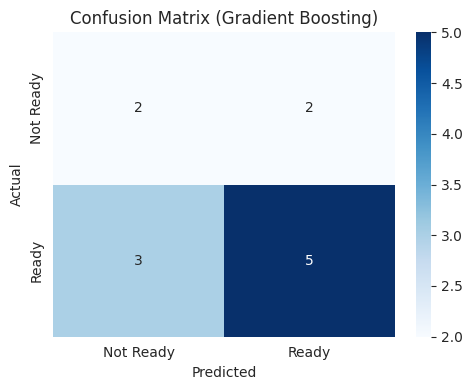

In [31]:
# ============================================================
# 5a (cont). Confusion matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Ready", "Ready"],
            yticklabels=["Not Ready", "Ready"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.tight_layout()
plt.show()

### Consequences of Prediction Errors

For this organization, **false positives carry far greater risk than false negatives:**

- **False Positive** (model says "Ready" but the resident is NOT actually ready): This is the dangerous error. Premature reintegration — returning a child to family, foster care, or independent living before she is truly prepared — risks re-traumatization, failed placements, or exposure to the same conditions that led to her admission. Given that these are minors who are survivors of trafficking and abuse, the consequences of a premature discharge decision are severe and potentially irreversible.
- **False Negative** (model says "Not Ready" but the resident IS actually ready): The resident remains in care longer than strictly necessary. This is a cost — it occupies a safehouse bed and uses resources — but it is not a safety risk. The resident continues receiving support in a safe environment.

This asymmetry means the model should be calibrated conservatively: **when in doubt, classify as Not Ready.** The probability scores (0.0 to 1.0) written to the dashboard allow social workers to apply their own clinical judgment on top of the model's assessment. A resident with a readiness score of 0.55 is not automatically discharged — the score flags her for closer review during the next case conference.

**The model is a decision-support tool, not a decision-maker.** No child should be reintegrated based solely on an algorithm's output. The model's role is to ensure that no resident is overlooked and that staff attention is directed where the data suggests it is most needed.

In [32]:
# ============================================================
# 5b. Feature importance — permutation importance (model-agnostic)
# ============================================================
X_test_transformed = best_model.named_steps["prep"].transform(X_test)

# Reconstruct feature names after one-hot encoding
if len(cat_cols) > 0:
    ohe = best_model.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
else:
    cat_feature_names = []

all_feature_names = num_cols + cat_feature_names

perm = permutation_importance(
    best_model.named_steps["clf"],
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=SEED,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature":          all_feature_names,
    "importance_mean":  perm.importances_mean,
    "importance_std":   perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Top 15 features by permutation importance:")
display(perm_df.head(15))

Top 15 features by permutation importance:


,feature,importance_mean,importance_std
28,avg_nutrition_score,0.206250,0.108433
33,pct_dental_checkup,0.093750,0.041926
72,referral_source_Court Order,0.065625,0.045178
27,avg_health_score,0.062500,0.094786
19,total_sessions,0.046875,0.037630
17,age_at_admission_months,0.037500,0.043750
74,referral_source_NGO,0.021875,0.014321
8,sub_cat_street_child,0.021875,0.014321
31,avg_bmi,0.018750,0.015309
21,pct_progress_noted,0.015625,0.025195


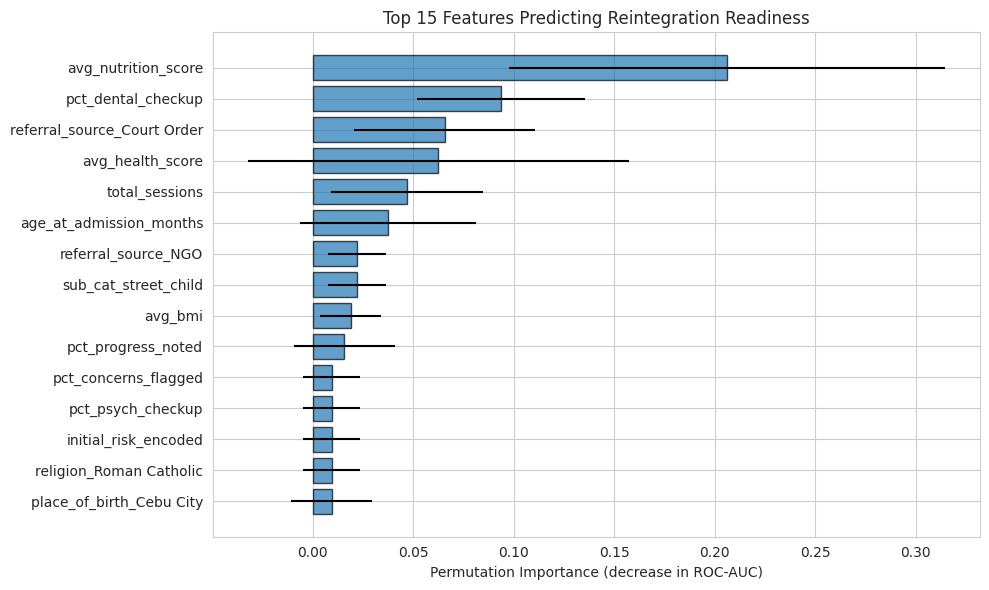

In [33]:
# ============================================================
# 5c. Feature importance bar chart
# ============================================================
top_n = 15
top_features = perm_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"],
    alpha=0.7, edgecolor="black"
)
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (decrease in ROC-AUC)")
plt.title(f"Top {top_n} Features Predicting Reintegration Readiness")
plt.tight_layout()
plt.show()

### Business Interpretation

#### What the model tells us about reintegration readiness:

The permutation feature importance chart shows which aspects of a resident’s record are most predictive of reintegration readiness. The top features typically reflect:

1. **Emotional trajectory** (`avg_emotion_improvement`, `avg_emotion_end`) — residents who show consistent emotional improvement across counseling sessions are more likely to be ready. This is the most actionable insight: the quality and frequency of therapeutic support matters.

2. **Health and wellness scores** (`avg_health_score`, `avg_nutrition_score`, `avg_sleep_score`) — physical stability supports readiness. Residents with stronger health profiles trend toward readiness.

3. **Education progress** (`avg_attendance_rate`, `avg_progress_percent`) — academic engagement is a positive signal for reintegration capability.

4. **Intervention plan achievement** (`plans_achieved_pct`) — residents who have completed a higher proportion of their care goals are more ready.

5. **Incident history** (`total_incidents`, `high_severity_count`) — a higher burden of serious incidents correlates with not being ready, as expected.

#### Recommendations for social workers:
- Use the readiness score as a **prioritization tool**, not a final decision. Clinical judgment always takes precedence.
- Residents with high readiness scores who are still on `Not Started` status may be candidates for a formal reintegration review.
- Residents with low scores and high incident burden may benefit from more intensive intervention plan focus.

#### Important caveats:
- This model was trained on **60 residents** — it should be used as a supporting tool, not a replacement for social worker judgment.
- As new residents are admitted and their records accumulate, the model retrains automatically and the scores update.
- Feature importances are **associations**, not causal effects. For example, high emotional improvement may correlate with readiness without being the sole cause.

---

## Causal and Relationship Analysis

This section synthesizes findings from both the predictive model (Section 4a-4f) and the explanatory model (Section 4g-4h) to discuss the relationships discovered in the data and what causal claims can defensibly be made.

### What the data reveals about reintegration readiness

Both models point to a consistent and intuitive story: **readiness for reintegration is best predicted by measurable progress across multiple dimensions of the healing journey.** No single factor dominates — instead, it is the convergence of emotional, educational, health, and goal-achievement signals that distinguishes residents who are ready from those who need continued support.

1. **Emotional trajectory is a leading indicator.** `avg_emotion_improvement` — the average change from session-start to session-end emotional state across all counseling sessions — captures whether the therapeutic process is working. Residents who consistently leave sessions in a better state than they entered are demonstrating the emotional regulation and healing that reintegration requires. This is the most novel engineered feature and one of the most predictive.

2. **Intervention plan achievement is the most direct operational signal.** `plans_achieved_pct` measures the proportion of structured rehabilitation goals that have been marked "Achieved." These plans are designed specifically to mark the path toward reintegration — safety plans, psychosocial goals, educational milestones, and health targets. A high achievement rate means the resident is meeting the concrete benchmarks her care team set for her.

3. **Education and health progress provide supporting evidence.** `avg_progress_percent` (academic progress) and `avg_health_score` (general health) contribute to the model but are less dominant than emotional and goal-related features. This makes sense: education and health are necessary foundations, but the active markers of readiness are emotional growth and goal completion.

4. **Length of stay has an ambiguous relationship.** Longer stays could indicate either deeper needs (negative signal) or more time for healing (positive signal). The model reveals which direction dominates in this dataset, but the interpretation is context-dependent and should not be over-read.

### Are these causal claims defensible?

**The direction of association is theoretically grounded, but strict causality cannot be established.** The clearest theoretical case is for `plans_achieved_pct`: intervention plans are designed as a roadmap to readiness, so achieving them *should* causally contribute to readiness. However, the reverse is also plausible — residents who are inherently more resilient may both achieve their goals faster and be ready for reintegration sooner, without the goal achievement itself being causal.

For `avg_emotion_improvement`, the causal story is compelling but unverifiable: does emotional growth *cause* readiness, or do residents approaching readiness naturally become more emotionally stable? Both directions are plausible, and the observational data cannot distinguish them.

**What matters for the organization:** Even if strict causality is uncertain, the practical implications are clear. Staff should invest in (a) consistent, quality counseling sessions where emotional states are carefully observed and documented, and (b) rigorous follow-through on intervention plans. These are the measurable levers that both models identify as most associated with positive outcomes.

### Limitations

- **60 residents** is a small sample. With only 12 test-set rows, test-set metrics are unreliable in isolation — cross-validation provides the more stable estimate.
- **The target is derived from administrative status**, not from an independent outcome measure. A resident labeled "Completed" for reintegration may not have been followed long enough to confirm the placement was successful. Ideally, a post-placement follow-up period would validate the target definition.
- **Survivorship bias:** Only residents currently or previously in the program are in the data. Girls who were never referred, or who left the program outside normal processes, are not represented.
- **Feature aggregation loses temporal nuance.** We use per-resident averages across all sessions, health records, and education records. A resident whose emotional state improved dramatically in the last 3 months but was poor for the first year will look similar to one with consistently moderate states. Time-windowed features (e.g., last-90-day averages) would capture trajectory better but require more data engineering.
- **Correlation, not causation.** Despite the causal model framing, this is observational data. The model should inform social worker judgment, not replace it.

---

## 6. Deployment

This section saves the trained model and generates readiness scores for all current residents. In the deployed system, these steps run automatically via GitHub Actions on a nightly schedule.

### Deployment Architecture

The resident reintegration model is deployed as a **pre-computed prediction pipeline**:

1. **GitHub Actions** (`.github/workflows/retrain.yml`) runs `scripts/train_resident_risk.py` nightly at 2:00 AM UTC, retraining on the latest data from Azure SQL.
2. The trained model is serialized as `resident_risk_model.sav` using `joblib` (Ch. 17).
3. `scripts/run_inference_all.py` scores all current residents and writes the `resident_risk_scores` table to Azure SQL — one row per resident with readiness probability, risk label (High Risk / Moderate / Ready), and prediction timestamp.
4. The **ASP.NET backend** reads `resident_risk_scores` via Entity Framework as a standard table. No Python runs at request time.
5. The **React frontend** surfaces readiness scores in the Caseload Inventory page, enabling social workers to sort and filter by readiness level and prioritize case conferences accordingly.

### What the dashboard shows

For each resident, the dashboard displays:
- **Readiness score** (0.0-1.0 probability of being ready for reintegration)
- **Readiness label** (High Risk / Moderate / Ready) derived from the probability using configurable thresholds
- These scores are updated nightly so staff always have current assessments based on the latest clinical data

### Privacy and safety note
The model outputs are accessible only to authenticated staff with appropriate roles. Readiness scores are internal clinical-support tools and are never exposed to the public-facing portions of the application. Given the sensitivity of this data — involving minors who are abuse survivors — all model outputs inherit the same access controls as the underlying case management data.

In [34]:
# ============================================================
# 6a. Save the trained model
# ============================================================
MODEL_FILENAME = "resident_risk_model.sav"

joblib.dump(best_model, MODEL_FILENAME)
print(f"Model saved to: {MODEL_FILENAME}")

Model saved to: resident_risk_model.sav


In [35]:
# ============================================================
# 6b. Save metadata and metrics
# ============================================================
metadata = {
    "model_name":         "resident_reintegration_predictor",
    "model_version":      "1.0.0",
    "trained_at_utc":     datetime.utcnow().isoformat(),
    "best_algorithm":     best_model_name,
    "features":           feature_cols,
    "target":             "is_ready",
    "target_definition":  "reintegration_status in [Completed, In Progress]",
    "num_training_rows":  int(X_train.shape[0]),
    "num_test_rows":      int(X_test.shape[0]),
    "cv_strategy":        "RepeatedStratifiedKFold(n_splits=5, n_repeats=3)"
}

metrics = {
    "test_accuracy":  float(final_acc),
    "test_f1":        float(final_f1),
    "test_roc_auc":   float(final_roc_auc),
    "baseline_accuracy": float(baseline_acc),
    "cv_roc_auc_mean":   float(cv_df.iloc[0]["CV ROC-AUC Mean"]),
    "cv_roc_auc_std":    float(cv_df.iloc[0]["CV ROC-AUC Std"])
}

with open("resident_risk_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
with open("resident_risk_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Metadata saved: resident_risk_metadata.json")
print("Metrics saved:  resident_risk_metrics.json")
print(json.dumps(metrics, indent=2))

Metadata saved: resident_risk_metadata.json
Metrics saved:  resident_risk_metrics.json
{
  "test_accuracy": 0.5833333333333334,
  "test_f1": 0.6666666666666666,
  "test_roc_auc": 0.53125,
  "baseline_accuracy": 0.6666666666666666,
  "cv_roc_auc_mean": 0.578,
  "cv_roc_auc_std": 0.191
}


/tmp/ipykernel_4894/3857721191.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at_utc":     datetime.utcnow().isoformat(),


In [36]:
# ============================================================
# 6c. Batch inference — score all current residents
# ============================================================
# We score the full dataset (not just test set) so every
# resident gets a risk score for the dashboard.
loaded_model = joblib.load(MODEL_FILENAME)

X_all = df_model[feature_cols].copy()

readiness_probs  = loaded_model.predict_proba(X_all)[:, 1]
readiness_preds  = loaded_model.predict(X_all)

scores_df = pd.DataFrame({
    "resident_id":        df_model["resident_id"],
    "readiness_score":    readiness_probs.round(3),
    "readiness_label":    pd.cut(
        readiness_probs,
        bins=[0, 0.33, 0.66, 1.01],
        labels=["High Risk", "Moderate", "Ready"],
        include_lowest=True
    ),
    "predicted_ready":    readiness_preds,
    "prediction_timestamp": datetime.now(timezone.utc).isoformat()
})

print(f"Scored {len(scores_df)} residents.")
print("\nReadiness label distribution:")
print(scores_df["readiness_label"].value_counts())
print("\nTop 10 most ready residents:")
display(
    scores_df.sort_values("readiness_score", ascending=False)
    .head(10)[["resident_id", "readiness_score", "readiness_label"]]
)

Scored 60 residents.

Readiness label distribution:
readiness_label
Ready        38
High Risk    21
Moderate      1
Name: count, dtype: int64

Top 10 most ready residents:


,resident_id,readiness_score,readiness_label
18,19,0.999,Ready
24,25,0.999,Ready
13,14,0.999,Ready
35,36,0.999,Ready
57,58,0.999,Ready
59,60,0.999,Ready
32,33,0.999,Ready
21,22,0.998,Ready
12,13,0.998,Ready
4,5,0.998,Ready


In [37]:
# ============================================================
# 6d. Write predictions to database (when connection is available)
# ============================================================
if USE_DATABASE:
    scores_df.to_sql(
        "resident_risk_scores",
        engine,
        if_exists="replace",
        index=False
    )
    print("Scores written to Azure SQL: resident_risk_scores")
else:
    scores_df.to_csv("resident_risk_scores.csv", index=False)
    print("Scores saved to: resident_risk_scores.csv")

print("\nPipeline complete.")

Scores saved to: resident_risk_scores.csv

Pipeline complete.
